# XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance
### XGBoost Model

This is the second notebook of the project **"XGBoost MI Pricing — Explainable Machine Learning for Mortgage Insurance"**

This notebook attempts to fit an XGBoost ML Algorithm to the loan-level data to predict the mortgage insurance premium rates on these. The data is first split into train and test datasets. Both the datasets are then preprocessed to clean up the data (fill in missing values) and convert categorical values into dummy variables for modelling. 

To train the model, we use a K-Fold cross validation and Randomized CV Search to find the optimal parameters "max_depth" and "number_of_rounds" of the XGBoost model. These parameters are extremely essential to be optimized otherwise the model would overfit the data. 

We use the parameters to train the model on training dataset and use the test dataset to evaluate the results of the model using $R^2$ and RMSE. We also plot the Actual vs Predicted premium rate graph along with a plot of residuals to check the fit and validate the model. 

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels
import import_ipynb
import importlib
from IPython.display import display
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,make_scorer
from sklearn.impute import SimpleImputer
from mpl_toolkits.mplot3d import Axes3D
import joblib

In [2]:
#Load Loan Level Data
loan_level_data = pd.read_excel("00_LoanData.xlsx")

In [3]:
#Look at the first few rows of the dataset
loan_level_data.head(5)

,Loan ID,Loan Purpose,Occupancy Type,Property State,Original FICO Score,Original LTV (%),Original Loan Balance ($),Age of Loan (Months),Original Interest Rate (%),Current Loan Balance ($),Original DTI (%),Multiple Borrowers,Delinquency Status,MI Premium Rate (bps)
0,LN00000001,Purchase,Second Home,FL,737,80.97,479000,17,6.688,471578.07,27.6,No,Current,31.5
1,LN00000002,Refinance,Second Home,PA,716,90.45,256000,9,7.490,254243.27,29.2,Yes,Current,25.1
2,LN00000003,Refinance,Primary Residence,GA,792,95.15,340000,4,6.364,338727.61,37.4,No,Current,43.4
3,LN00000004,Purchase,Primary Residence,TX,773,86.79,334000,8,6.672,331618.12,38.6,Yes,Current,14.0
4,LN00000005,Purchase,Primary Residence,KY,746,93.06,305000,14,7.408,301639.44,33.3,Yes,Current,29.0


In [4]:
#List of Numerical and Categorical Features
num_feats = ['Original Loan Balance ($)','Original FICO Score','Original LTV (%)','Original Interest Rate (%)','Original DTI (%)']
cat_feats = ['Loan Purpose','Occupancy Type','Property State','Multiple Borrowers']

In [5]:
#Defining Target Variable and Independent Variates
X = loan_level_data[num_feats+cat_feats]
Y = loan_level_data['MI Premium Rate (bps)']

In [6]:
#Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#Drop Index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
Y_train = Y_train.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)

In [10]:
# For numeric features replace missing values with median
num_transformer = SimpleImputer(strategy='median')

# For categorical features just impute, no OHE
cat_transformer = SimpleImputer(strategy='most_frequent')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_feats),
        ('cat', cat_transformer, cat_feats),
    ]
)

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Convert back to DataFrame and restore category dtype
feature_names = num_feats + cat_feats
X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

#Ensure categorical columns are category type
for col in cat_feats:
    X_train_transformed[col] = X_train_transformed[col].astype('category')
    X_test_transformed[col] = X_test_transformed[col].astype('category')

# Also ensure numeric columns are float
for col in num_feats:
    X_train_transformed[col] = X_train_transformed[col].astype(float)
    X_test_transformed[col] = X_test_transformed[col].astype(float)

We look at different options from max_depth of each tree and number of trees required by keeping the learning rate constant. 
This would help us understand where early stopping has to be applied and we can train the model till 'n' number of trees. 
We would also use KFold Cross Validation to detect overfitting and help avoid it.

In [11]:
fixed_learning_rate = 0.05

if __name__ == '__main__':
    #Calibrating the parameters of the XGBoost model
    fixed_learning_rate = 0.05

    #Base Model
    model = xgb.XGBRegressor(
        objective = 'reg:squarederror',
        learning_rate = fixed_learning_rate,
        subsample = 0.8, 
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1,
        reg_alpha = 0,
        tree_method = 'hist',
        random_state=42,
        n_jobs=-1,
        enable_categorical=True
    )

    #Checking different options for max_depth and number_of_estimators
    param_dist = {
        "max_depth": [1,2,3,4,5,6,7,8,9],
        "n_estimators": [200,400,600,800,1000,1500]
    }

    #Model Evaluation Metrics
    scoring = {
        "r2": make_scorer(r2_score),
        "rmse": 'neg_root_mean_squared_error'
    }

    #Cross Validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    #Randomised Search CV
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=25,
        scoring=scoring,
        refit='r2',
        cv=cv,
        random_state=42,
        n_jobs=-1,
        return_train_score=True,
        verbose=0
    )

    #Fit the model
    search.fit(X_train_transformed,Y_train)

    #Extract Results
    temp_df = pd.DataFrame(search.cv_results_)

    #Convert RSME
    temp_df['mean_train_rmse'] = -temp_df['mean_train_rmse']
    temp_df['mean_test_rmse'] = -temp_df['mean_test_rmse']

    #Results DataFrame
    results_df = pd.DataFrame({
        'max_depth': temp_df['param_max_depth'].astype(int),
        'n_estimators': temp_df['param_n_estimators'].astype(int),
        'train_r2': temp_df['mean_train_r2'].astype(float),
        'valid_r2': temp_df['mean_test_r2'].astype(float),
        'train_rmse': temp_df['mean_train_rmse'].astype(float),
        'valid_rmse': temp_df['mean_test_rmse'].astype(float)
    })

    #Print Results
    display(results_df.head())

,max_depth,n_estimators,train_r2,valid_r2,train_rmse,valid_rmse
0,4,400,0.897975,0.891314,6.133526,6.330149
1,9,400,0.951862,0.884400,4.213018,6.528342
2,9,200,0.933377,0.886362,4.956425,6.472751
3,3,200,0.893319,0.891308,6.271912,6.330310
4,8,600,0.947433,0.885001,4.402621,6.511385


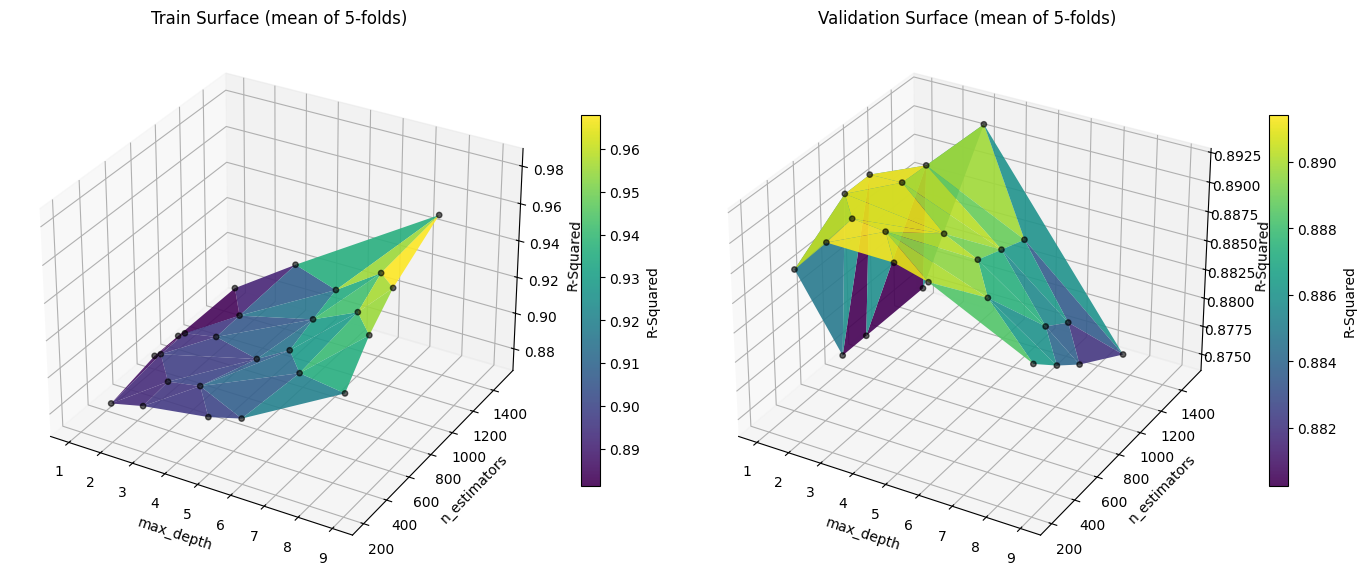

In [12]:
if __name__ == '__main__':
    #Plot R^2
    x= results_df['max_depth'].astype(float).values
    y = results_df['n_estimators'].astype(float).values
    z_train = results_df['train_r2'].astype(float).values
    z_valid = results_df['valid_r2'].astype(float).values

    fig = plt.figure(figsize=(14,6))

    #Train Surface
    ax1 = fig.add_subplot(1,2,1,projection='3d')
    surf1 = ax1.plot_trisurf(x,y,z_train, cmap='viridis', alpha=0.9, linewidth=0.2, edgecolor='none')
    ax1.scatter(x,y,z_train, c='k', s=15, alpha=0.6)
    ax1.set_title(f"Train Surface (mean of 5-folds)")
    ax1.set_xlabel("max_depth")
    ax1.set_ylabel("n_estimators")
    ax1.set_zlabel("R-Squared")
    fig.colorbar(surf1, ax=ax1, shrink=0.65, label='R-Squared')

    #Validation Surface
    ax2 = fig.add_subplot(1,2,2,projection='3d')
    surf2 = ax2.plot_trisurf(x,y,z_valid, cmap='viridis', alpha=0.9, linewidth=0.2, edgecolor='none')
    ax2.scatter(x,y,z_valid, c='k', s=15, alpha=0.6)
    ax2.set_title(f"Validation Surface (mean of 5-folds)")
    ax2.set_xlabel("max_depth")
    ax2.set_ylabel("n_estimators")
    ax2.set_zlabel("R-Squared")
    fig.colorbar(surf2, ax=ax2, shrink=0.65, label='R-Squared')
    plt.savefig("images/hyperparameter_selection.png", dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

The validation $R^2$ surface peaks around max_depth of 3 to 4 before declining at higher depths, indicating overfitting as trees become too complex. The optimal parameters are selected at this peak to balance model fit and generalisation.

In [13]:
if __name__ == '__main__':
    #Best by Validation R-Square
    best_by_r2_idx = results_df['valid_r2'].idxmax()
    best_by_r2 = results_df.loc[best_by_r2_idx]
    print("Best Combination by Validation R-Sqaure:")
    print(best_by_r2)
    print("\n")

    #Best by Validation RMSE
    best_by_rmse_idx = results_df['valid_rmse'].idxmin()
    best_by_rmse = results_df.loc[best_by_rmse_idx]
    print("Best Combination by Validation RMSE:")
    print(best_by_rmse)
    print("\n")

Best Combination by Validation R-Sqaure:
max_depth         3.000000
n_estimators    400.000000
train_r2          0.894919
valid_r2          0.891603
train_rmse        6.224706
valid_rmse        6.321702
Name: 10, dtype: float64


Best Combination by Validation RMSE:
max_depth         3.000000
n_estimators    400.000000
train_r2          0.894919
valid_r2          0.891603
train_rmse        6.224706
valid_rmse        6.321702
Name: 10, dtype: float64




In [14]:
#Train the Final Model
if __name__ == '__main__':
    best_rounds = search.best_params_['n_estimators']  #From above K-Fold validation across different combinations
    best_max_depth = search.best_params_['max_depth']  #From above K-Fold validation across different combinations
else:
    best_rounds = 800  #From above K-Fold validation across different combinations #Make sure to change for shapley calculations
    best_max_depth = 3  #From above K-Fold validation across different combinations 


#Give Parameters
xgboost_model_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    learning_rate = fixed_learning_rate,
    max_depth = best_max_depth,
    n_estimators = best_rounds,
    subsample = 0.8, 
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=1,
    reg_alpha = 0,
    tree_method = 'hist',
    random_state = 42,
    n_jobs=-1,
    enable_categorical=True
)

#Fit the model
xgboost_model_final.fit(X_train_transformed, Y_train)

#Predict on the test data-set
preds = xgboost_model_final.predict(X_test_transformed)

#Evaluation of the model
r2 = r2_score(Y_test, preds)
rmse = float(np.sqrt(mean_squared_error(Y_test,preds)))
mae = float(mean_absolute_error(Y_test, preds))

if __name__ == '__main__':
    print(f"The final test RMSE @ {best_rounds} trees: {rmse:.4f}")
    print(f"The final test MAE @ {best_rounds} trees: {mae:.4f}")
    print(f"The final test R-Squared @ {best_rounds} trees: {r2:.4f}")

#DataFrame of Test Predictions
test_pred_df = pd.DataFrame({
    'y_true': Y_test,
    'y_pred': preds,
    'residuals': Y_test-preds
})

The final test RMSE @ 400 trees: 6.2684
The final test MAE @ 400 trees: 5.0305
The final test R-Squared @ 400 trees: 0.8910


The final model achieves an $R^2$ of 0.89 on the held-out test set, explaining 89% of the variance in MI premium rates. RMSE of 6.28 bps and MAE of 5.04 bps indicate the model's predictions are on average within 5 bps of the actual premium. This is a reasonable margin given the inherent noise in premium rates not fully explained by observable loan characteristics.

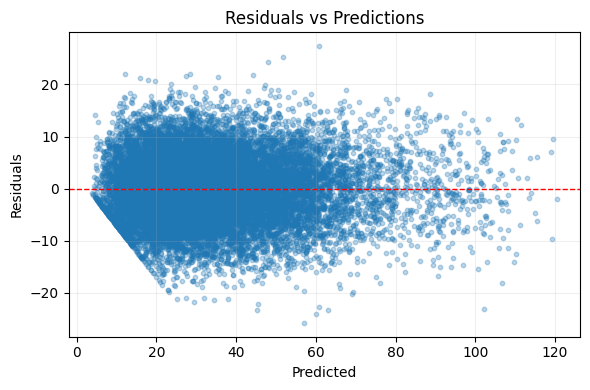

In [15]:
#Plot the residuals to check if they are random
if __name__ == '__main__':
    plt.figure(figsize=(6,4))
    plt.scatter(preds, Y_test-preds, alpha=0.3, s=10)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residuals vs Predictions")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

15:11Residuals are randomly scattered around zero with no systematic bias, indicating the model is well calibrated across the full premium range. The widening spread at higher predicted values reflects heteroscedasticity. High risk loans have greater inherent pricing variability which the model cannot fully capture, and is expected given the nature of MI pricing.

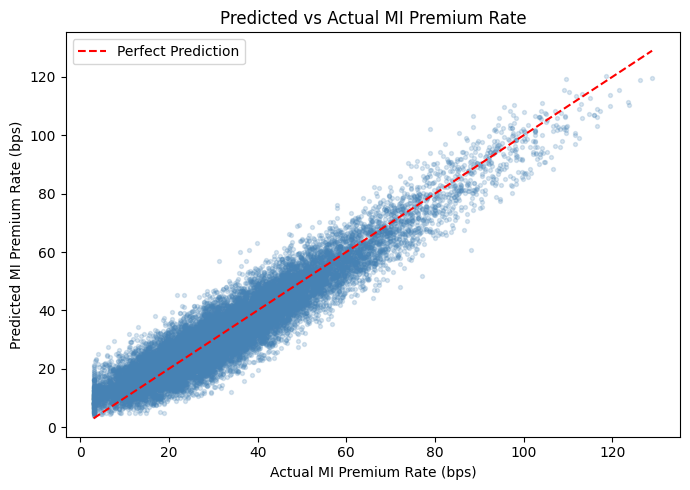

In [16]:
# Plot the Predicted vs Actual Rates
if __name__ == '__main__':
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(Y_test, preds, alpha=0.2, s=8, color='steelblue')
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual MI Premium Rate (bps)')
    ax.set_ylabel('Predicted MI Premium Rate (bps)')
    ax.set_title('Predicted vs Actual MI Premium Rate')
    ax.legend()
    plt.tight_layout()
    plt.show()

The slight widening of the cloud at higher actual values (above 80 bps) is consistent with the heteroscedasticity in the residuals plot. High risk loans have more inherent pricing variability which the model can't fully capture, and that's expected.
The small cluster of points near zero predicted but with actual values of 10-20 bps is the low-premium prime borrower segment. The model is slightly conservative there, which in a real MI context is actually the safer direction to err.

### End of Notebook